# Market Analysis

        На этом этапе проводится анализ рынка квартир Москвы после очистки данных, извлечения признаков и удаления экстремальных значений по 1-му и 99-му процентилям.

        Цель анализа - получить ключевые рыночные метрики, сравнить сегменты по комнатности, годам и станциям метро, а также подготовить бизнес-выводы для банковского кейса по оценке ипотечного залога.

## 1. Импорт библиотек и загрузка данных

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", palette="muted")

In [4]:
data_path = "data/moscow_flats_clean.csv.gz"

flats = pd.read_csv(data_path)

In [ ]:
flats.head()

## 2. Контрольная проверка качества данных

        Перед анализом проверим размер датасета, типы данных, пропуски и базовую статистику по ключевым числовым признакам.

In [ ]:
flats.info()

In [ ]:
flats.isna().sum().sort_values(ascending=False).head(20)

In [ ]:
flats[["price", "area", "rooms", "price_per_m2"]].describe().round(0)

## Вывод

        Датасет содержит только квартиры после предварительной очистки и удаления экстремальных значений. Для дальнейшего анализа ключевыми признаками являются цена, площадь, количество комнат, цена за квадратный метр, метро и год публикации.

        В качестве основной метрики стоимости используется `price_per_m2`, потому что она позволяет сравнивать квартиры разной площади между собой.

## 3. Основные рыночные метрики

In [5]:
main_metrics = pd.DataFrame({
            "metric": [
                "listings",
                "median_price",
                "median_price_per_m2",
                "median_area",
                "median_rooms",
                "unique_metro_stations"
            ],
            "value": [
                len(flats),
                flats["price"].median(),
                flats["price_per_m2"].median(),
                flats["area"].median(),
                flats["rooms"].median(),
                flats["metro"].nunique()
            ]
        })

main_metrics

,metric,value
0,listings,"1,384,363.00"
1,median_price,"17,980,000.00"
2,median_price_per_m2,"344,919.79"
3,median_area,54.00
4,median_rooms,2.00
5,unique_metro_stations,388.00


## Вывод

        Медианные значения используются вместо средних, потому что рынок недвижимости содержит дорогие премиальные объекты, которые могут искажать среднее значение.

        Эти метрики описывают массовый рынок квартир и будут использоваться как базовый ориентир для дальнейшей оценки справедливой стоимости объекта.

## 4. Анализ по количеству комнат

In [6]:
rooms_stats = flats.groupby("rooms").agg(
            listings=("price", "size"),
            median_price=("price", "median"),
            median_price_per_m2=("price_per_m2", "median"),
            median_area=("area", "median")
        ).reset_index()

rooms_stats.round(0)

,rooms,listings,median_price,median_price_per_m2,median_area
0,1,433721,"12,700,000.00","340,625.00",38.00
1,2,538331,"17,500,000.00","334,052.00",55.00
2,3,324223,"26,452,382.00","350,000.00",76.00
3,4,74753,"48,500,000.00","440,000.00",108.00
4,5,11446,"76,348,873.00","515,028.00",148.00
5,6,1889,"81,900,000.00","473,404.00",174.00


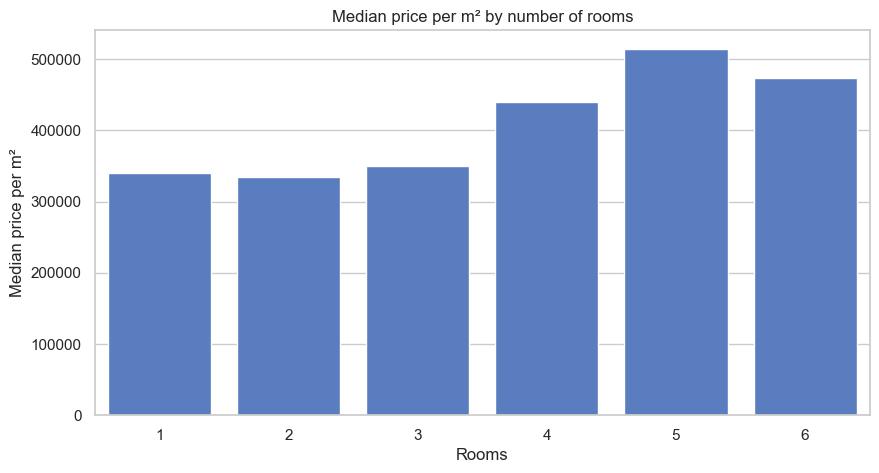

In [7]:
plt.figure(figsize=(10, 5))
sns.barplot(
            data=rooms_stats,
            x="rooms",
            y="median_price_per_m2"
        )
plt.title("Median price per m² by number of rooms")
plt.xlabel("Rooms")
plt.ylabel("Median price per m²")
plt.show()

## Вывод

        Сравнение по комнатности показывает, как меняется стоимость квадратного метра в разных сегментах. Это важно для банковской оценки, потому что однокомнатные, семейные и крупные премиальные квартиры могут иметь разную логику ценообразования.

## 5. Динамика рынка по годам

In [8]:
year_stats = flats.groupby("request_year").agg(
            listings=("price", "size"),
            median_price=("price", "median"),
            median_price_per_m2=("price_per_m2", "median"),
            median_area=("area", "median")
        ).reset_index()

year_stats.round(0)

,request_year,listings,median_price,median_price_per_m2,median_area
0,2023,560578,"16,500,000.00","317,200.00",54.00
1,2024,442140,"18,129,552.00","352,517.00",54.00
2,2025,381645,"20,247,040.00","382,479.00",55.00


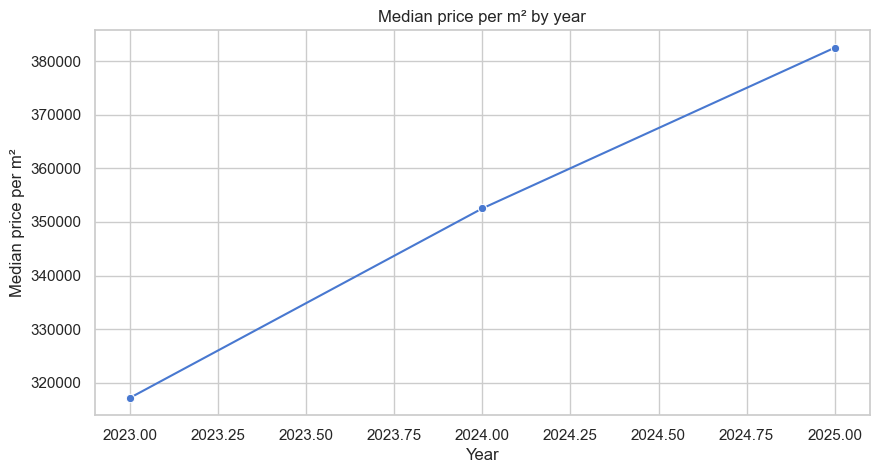

In [9]:
plt.figure(figsize=(10, 5))
sns.lineplot(
            data=year_stats,
            x="request_year",
            y="median_price_per_m2",
            marker="o"
        )
plt.title("Median price per m² by year")
plt.xlabel("Year")
plt.ylabel("Median price per m²")
plt.grid(True)
plt.show()

## Вывод

        Динамика медианной цены за квадратный метр показывает изменение рынка во времени. Для банка такая метрика полезна при мониторинге стоимости ипотечного залога и оценке рыночного риска.

## 6. Анализ по станциям метро

In [10]:
metro_stats = flats.groupby("metro").agg(
            listings=("price", "size"),
            median_price=("price", "median"),
            median_price_per_m2=("price_per_m2", "median"),
            median_area=("area", "median")
        ).reset_index()

metro_stats = metro_stats[metro_stats["listings"] >= 1000]
metro_stats = metro_stats.sort_values("median_price_per_m2", ascending=False)

metro_stats.head(20).round(0)

,metro,listings,median_price,median_price_per_m2,median_area
194,Новокузнецкая,2099,"86,900,000.00","1,029,000.00",89.00
63,Воробьёвы горы,1047,"88,503,000.00","948,903.00",90.00
13,Арбатская,1836,"88,000,000.00","944,222.00",98.00
20,Баррикадная,1785,"85,583,790.00","943,299.00",90.00
120,Краснопресненская,1671,"84,700,000.00","900,391.00",97.00
106,Китай-город,1275,"69,134,455.00","881,006.00",84.00
298,Спортивная,2899,"85,000,000.00","864,397.00",91.00
224,Парк Победы,3716,"68,537,165.00","856,512.00",84.00
331,Улица 1905 года,8851,"80,000,000.00","840,394.00",98.00
223,Парк Культуры,1524,"64,500,000.00","796,354.00",87.00


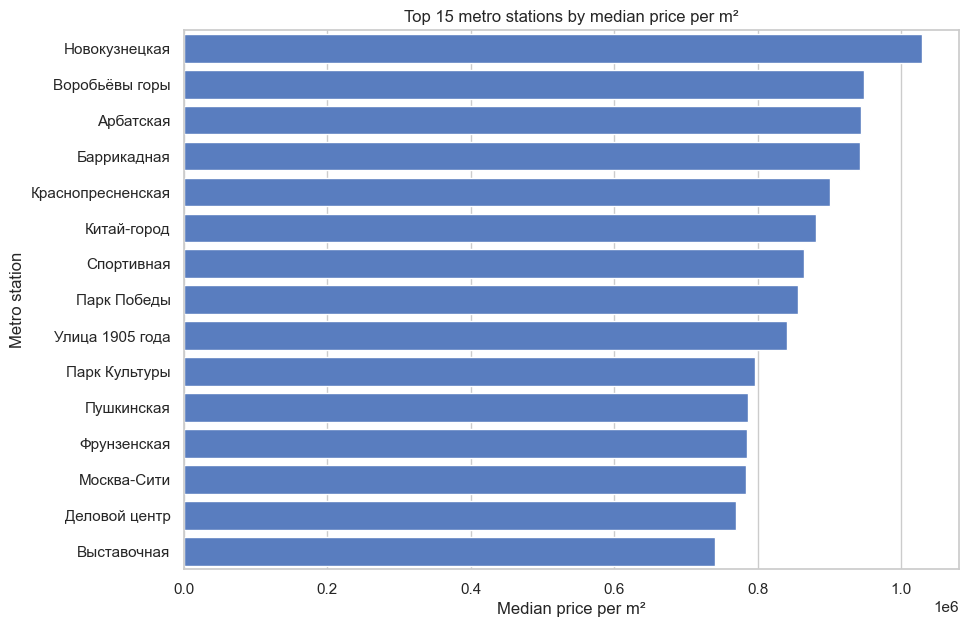

In [11]:
top_metro = metro_stats.head(15)

plt.figure(figsize=(10, 7))
sns.barplot(
            data=top_metro,
            x="median_price_per_m2",
            y="metro"
        )
plt.title("Top 15 metro stations by median price per m²")
plt.xlabel("Median price per m²")
plt.ylabel("Metro station")
plt.show()

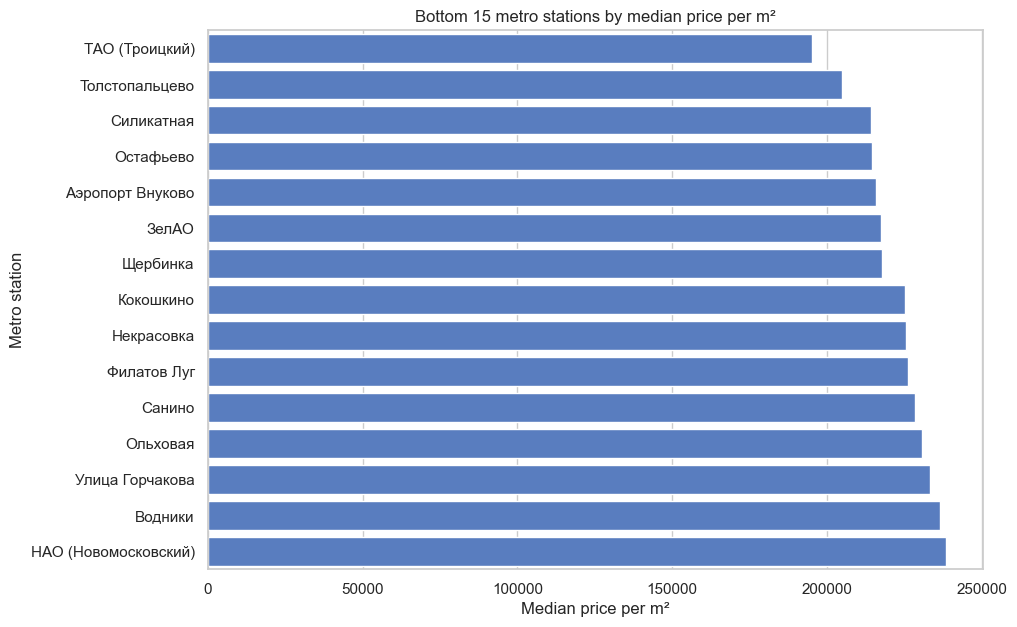

In [12]:
bottom_metro = metro_stats.tail(15).sort_values("median_price_per_m2")

plt.figure(figsize=(10, 7))
sns.barplot(
            data=bottom_metro,
            x="median_price_per_m2",
            y="metro"
        )
plt.title("Bottom 15 metro stations by median price per m²")
plt.xlabel("Median price per m²")
plt.ylabel("Metro station")
plt.show()

## Вывод

        Станция метро является одним из ключевых факторов стоимости квартиры. Разница между верхними и нижними станциями по медианной цене за квадратный метр может использоваться как географический индикатор рыночной стоимости и ликвидности объекта.

## 7. Распределение цены за квадратный метр

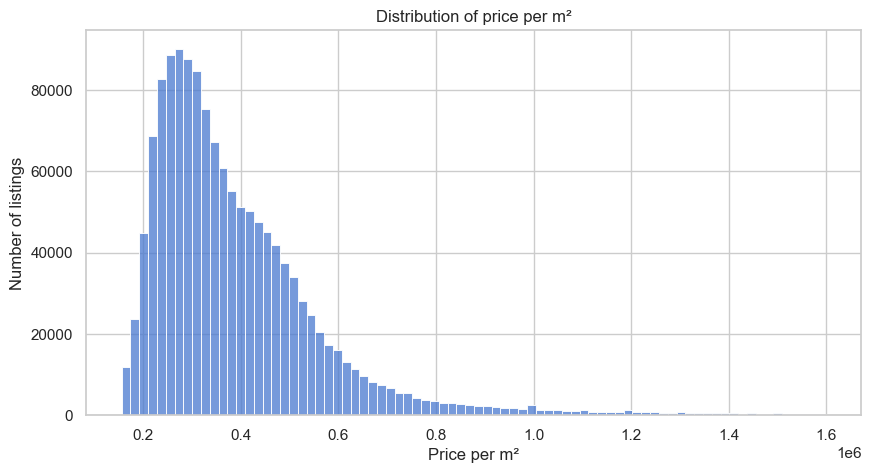

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(flats["price_per_m2"], bins=80)
plt.title("Distribution of price per m²")
plt.xlabel("Price per m²")
plt.ylabel("Number of listings")
plt.show()

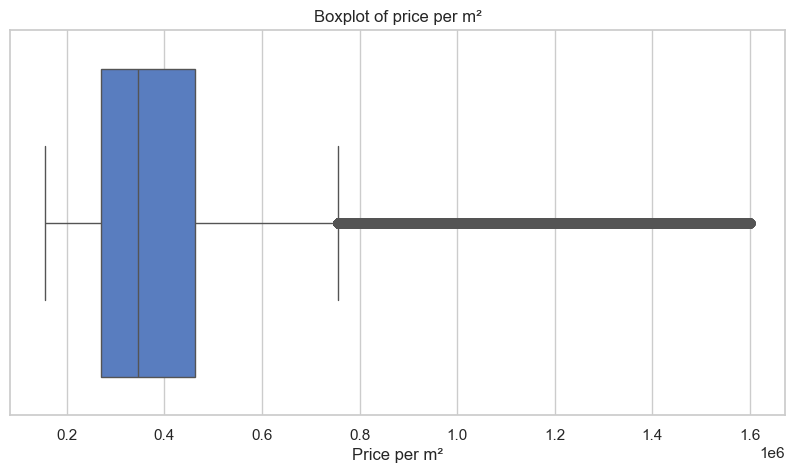

In [14]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=flats, x="price_per_m2")
plt.title("Boxplot of price per m²")
plt.xlabel("Price per m²")
plt.show()

## Вывод

        Распределение цены за квадратный метр помогает понять типичный уровень рынка и оставшиеся хвосты распределения после удаления экстремальных значений. Этот признак будет одним из главных ориентиров для будущей модели оценки справедливой стоимости.

## 8. Бизнес-выводы для банковского кейса

        - Очищенный датасет можно использовать для оценки массового рынка квартир Москвы.
        - Медианная цена за квадратный метр является ключевой метрикой для сравнения объектов разной площади.
        - Комнатность, площадь, метро и год публикации заметно связаны со стоимостью объекта.
        - Анализ по метро позволяет выделить дорогие и более доступные локации.
        - Следующий шаг проекта - построить модель справедливой цены квартиры и использовать отклонение фактической цены от модельной оценки как риск-индикатор для ипотечного залога.